# Daniel's Guide to Quantifying Uncertainty in Turbulence Statistics

Uncertainty in statistics comes from three main sources:
1. **Measurement uncertainty:** errors introduced during data acquisition, e.g. from instrument noise
2. **Sampling/statistical uncertainty:** variability that arises when trying to estimate ensemble averages from a finite dataset. Greater in the tails of distributions or at scales with fewer contributing points (see Kiyani et al.) 
3. **Fitting uncertainty:** uncertainty in the parameters, e.g., power-law exponents, Taylor scale, obtained from fitting a model (like a straight-line in log-log space)

## Next steps

*See [ChatGPT convo](https://chatgpt.com/share/67fcd8ab-c87c-8012-8888-f1c7be3bc7cc)*

- Tidy below
- Add remainder of stuff from notebook, esp. Kiyani
- Try pointwise bootstrapping of squared increments, compare.
- Try time series bootstrapping *by random removing points*. We have shown this is unbiased! 

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

## Measurement uncertainty

We often have uncertainty in our measurements due to **random/statistical** error. (There is separate component of measurement error called **systematic** error, which is a consistent offset to the true value and therefore can be easily corrected. It will not be discussed any further here.) We can represent this error as a random variable $\mathbf{\epsilon}$ that is added to the `true' value of our data $\mathbf{X}$, in order to get our observed values $\hat{\mathbf{X}}$:

$$\hat{\mathbf{X}}=\mathbf{X}+\mathbf{\epsilon}$$
Note that the measurement error is typically assumed to be independent and identically distributed (i.i.d.) across all observations, and independent of the true signal. Additionally, it is modeled as normally distributed with zero mean and variance $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$:

$$\mathbf{\epsilon}\sim N(0,\mathbf{\sigma}_{\mathbf{\epsilon}}^2)$$

We can get $\mathbf{\sigma}^2_\mathbf{\epsilon}$ by noting that typically data error bars in literature are expressed as $\mathbf{X}\pm\mathbf{\sigma}_\mathbf{\epsilon}$. (In some cases they may represent 95\% confidence intervals, in which case what is really expressed is $\mathbf{X}\pm1.96\mathbf{\sigma}_\mathbf{\epsilon}$.)

**This error does not affect the mean of our data**:

$$E[\hat{\mathbf{X}}]=E[\mathbf{X}+\mathbf{\epsilon}]=E[\mathbf{X}]+E[\mathbf{\epsilon}]=E[\mathbf{X}]$$

This follows from $E[A+B]=E[A]+E[B]$

**But it does inflate the variance**:

$$\text{Var}[\hat{\mathbf{X}}]=\text{Var}[\mathbf{X}+\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]+\text{Cov}[X,\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

This follows from $\text{Var}(A+B)=\text{Var}(A)+\text{Var}(B)+\text{Cov}(A,B)$

**Seeing as the second-order structure function $\text{SF}$ is a measure of variance, it is also inflated by measurement error.** And since it is a function of two random variables $X_i, X_j$, with the same error distribution, we get two times the error variance as our upwards bias:

$$E[\hat{\text{SF}}(\tau)]=\text{SF}(\tau)+2\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

The full derivation of this is given in [Cucchetti et al. (2019)](https://www.aanda.org/articles/aa/pdf/2019/09/aa35677-19.pdf), Appendix A.3 and [ZuHone, Markevitch, and Zhuravleva (2019)](https://iopscience.iop.org/article/10.3847/0004-637X/817/2/110/pdf), Appendix C. (In those papers, they represent $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$ as $\mathbf{\sigma}^2_{stat}$, to distinguish it from the systematic error variance $\mathbf{\sigma}^2_{sys}$.) They then show the downwards correction of this bias in their Figures 3 and 5, respectively:

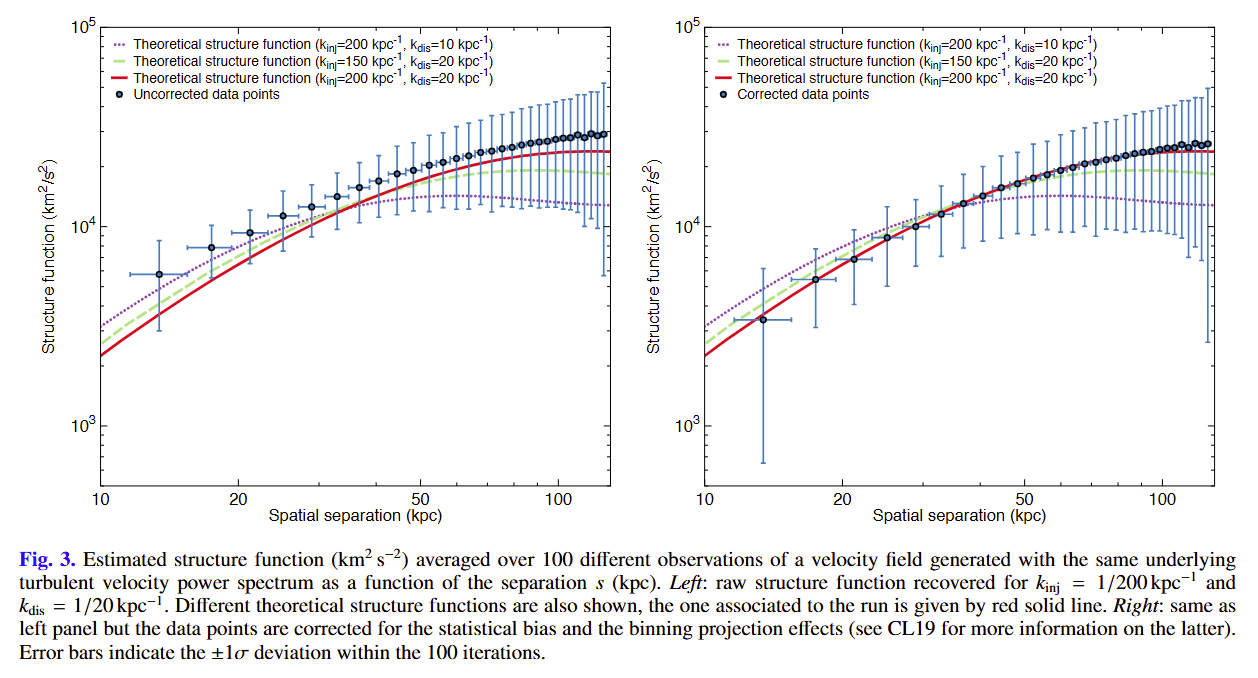

*^ From [Cucchetti et al. (2019)](https://www.aanda.org/articles/aa/pdf/2019/09/aa35677-19.pdf). In the right panel we can see that after subtracting the bias, the points lie much more in line with the red theoretical model.*

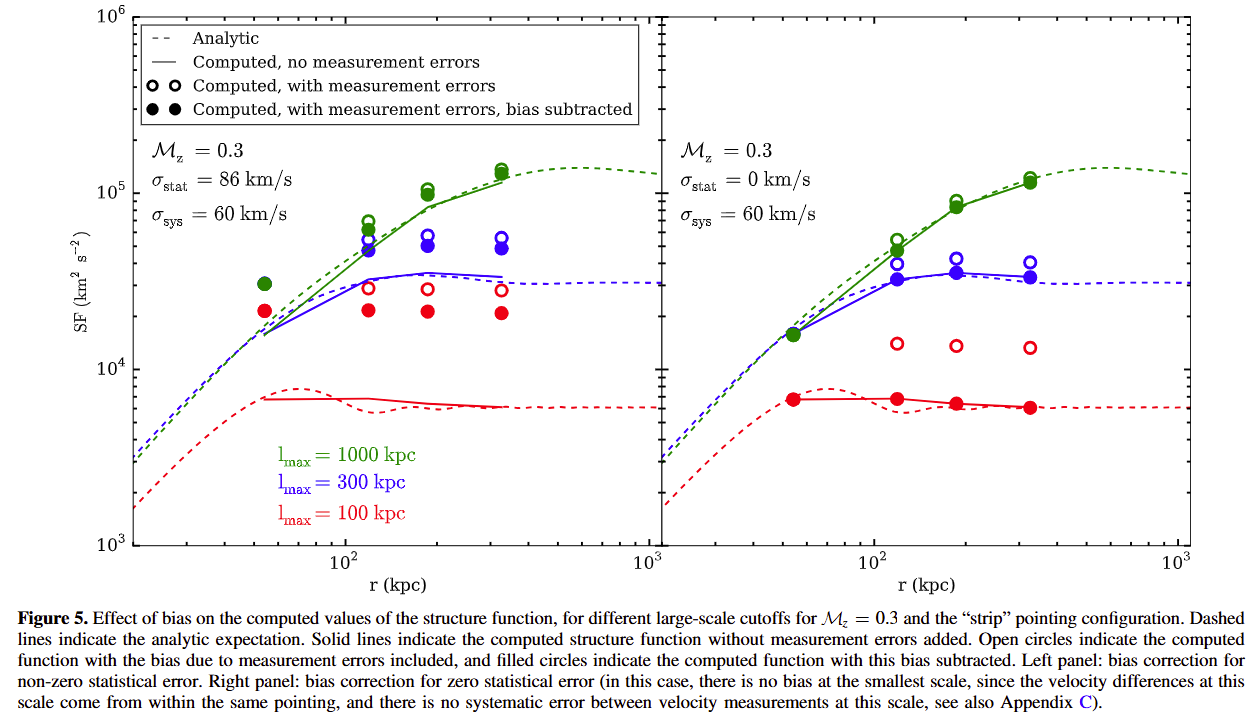

*^ From [ZuHone, Markevitch, and Zhuravleva (2019)](https://iopscience.iop.org/article/10.3847/0004-637X/817/2/110/pdf). Again, measurement errors cause upwards bias. Bias is strongest for the structure function with a small injection scale (red line). Their systematic error describes an error which is a constant offset within a given chunk of data (and therefore cancels out), but varies across chunks ('pointings'), and therefore needs modelling with a variance $\sigma_{sys}$. Given it does often cancel out, overall we see that statistical error is the dominant contributor to the bias.*

The former paper also derives the error that propagates into the four-term *variance* of the structure function, which we need for calculating confidence intervals:

$$\text{Var}[\hat{\text{SF}}(\tau)]=\text{Var}[\text{SF}(\tau)]+4\text{Var}[\text{D}(\tau)]\mathbf{\sigma}_{\mathbf{\epsilon}}^2+\frac{4}{N(\tau)}\text{SF}(\tau)\mathbf{\sigma}_{\mathbf{\epsilon}}^2+\frac{4(N_{nei}(\tau)+1)}{N(\tau)}\mathbf{\sigma}_{\mathbf{\epsilon}}^4$$

where $D(\tau)$ is the increment function (first-order SF), $N(\tau)$ is the number of lag pairs at lag $\tau$, and $N_{nei}(\tau)$ is the number of neighbours at a distance of $\tau$ at any given point.

If we have zero uncertainty in the data, this variance reduces to a single term: the 'intrinsic variance' of the structure function $\text{Var}[\text{SF}(\tau)]$. This is the uncertainty that results from sampling: see next section.

### Demo on simulated data

Typically fractional Brownian motion is simulated in turbulence analyses, but here we use an AR(1) process due to its more accurate multi-fractal nature (esp. plateau at large lags.)

In [105]:
# Simulate a time series with long-range correlations
# (AR(1) process shows better SF plateau than FBM)

from fbm import FBM
np.random.seed(43)

n = 1000  # Number of points

# Simulate fractional Brownian motion

hurst = 1/3  # Hurst parameter (0 < H < 1) = alpha/p for SF scaling
fbm_sim = FBM(n=n, hurst=hurst, length=1)
ts_sim = fbm_sim.fbm()

# Simulate AR(1) process
# phi = 0.9
# noise = np.random.normal(0, 1, n)
# ts_sim = np.zeros(n)
# for i in range(1, n):
#     ts_sim[i] = phi * ts_sim[i - 1] + noise[i]

In [87]:
# Define function to "bootstrap" structure functions from time series with noise


def simulate_noise(x, max_lag, sigma_eps=None, snr=None, n_samples=1000, data_name="", plot_minus=False):

    n = len(x)
    if sigma_eps is None:
        # Choose sigma such that the signal-to-noise ratio is snr
        sigma_eps = np.sqrt(np.var(x) / snr)
    if snr is None:
        # Calculate the signal-to-noise ratio
        snr = np.var(x) / sigma_eps**2

    # Remove any dated index (doesn't show up good in x-axis ticklabels)
    if type(x) == pd.Series:
        if type(x.index) == pd.DatetimeIndex:
            x.reset_index(drop=True, inplace=True)

    sf_true = sf_funcs.compute_sf(
        pd.DataFrame(x), np.arange(1, max_lag + 1), [2], False, False, None
    ).sf_2
    sf_noise = sf_funcs.compute_sf(
        pd.DataFrame(np.random.normal(0, sigma_eps, len(x))),
        np.arange(1, max_lag + 1),
        [2],
        False,
        False,
        None,
    ).sf_2

    sf_boot = np.zeros((n_samples, max_lag))

    x_boot_all = []


    for b in range(n_samples):

        x_boot = x + np.random.normal(0, sigma_eps, len(x))
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(

            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None


        ).sf_2

    # PLOT RESULTS
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    for x_boot in x_boot_all:
        ax[0].plot(x_boot, c="grey", alpha=0.1)
    ax[0].plot(
        x_boot[0],
        label=f"X +$\epsilon, \epsilon \sim N(0,\sigma^2_{{\epsilon}})$ ({n_samples} samples)",
        color="grey",
    )
    ax[0].plot(x, label=f"X ({data_name})", color="blue")
    # Reorder the legend
    handles, labels = ax[0].get_legend_handles_labels()
    handles = [handles[1], handles[0]]
    labels = [labels[1], labels[0]]
    ax[0].legend(handles, labels, loc="upper left")

    ci_lower = np.percentile(sf_boot, 2.5, axis=0)
    ci_upper = np.percentile(sf_boot, 97.5, axis=0)

    # Plot
    lags = np.arange(1, max_lag + 1)

    # Plot with both bootstrap and pointwise SE intervals using fig, ax[1] syntax[1]
    for sf in sf_boot:
        ax[1].plot(lags, sf, color="grey", alpha=0.2)
    ax[1].plot(lags, sf_true, label="SF(X)", color="blue")
    ax[1].plot(lags, sf_boot[0], color="grey", alpha=0.8, label="SF(X + $\epsilon_i$)")
    # ax[1].plot(
    #     lags, sf_noise.sf_2, label="SF($\epsilon_i$)", color="pink", alpha=0.8, lw=0.8
    # )
    ax[1].plot(
        lags,
        sf_true + 2 * sigma_eps**2,
        label="SF(X) + 2$\sigma_{\epsilon}^2$",
        color="purple",
        linestyle="--",
    )
    if plot_minus:
        ax[1].plot(
            lags,
            sf_true - 2 * sigma_eps**2,
            label="SF(X) - 2$\sigma_{\epsilon}^2$",
            color="black",
            linestyle="--",
        )
    # ax[1].plot(
    #     sf_true.lag[2:10],
    #     0.008 * np.power(sf_true.lag[2:10], 2 / 3),
    #     label="$\\tau^{2/3}$",
    #     color="black",
    #     linestyle=":",
    #     alpha=0.3,
    # )

    # ax[0].set_ylim(ts.min()-0.01, ts.max()+0.01)
    ax[0].set_title(
        f"Time series with added noise: ${{\sigma}}_{{\epsilon}}=${sigma_eps:.2f}, SNR={snr:.2f}"
    )
    ax[1].set_title(f"Corresponding structure functions")

    ax[1].set_xlabel("Lag (τ)")
    ax[1].set_xscale("log")
    ax[1].set_yscale("log")
    # ax[1].set_ylim(0.01, 10)
    ax[1].legend()
    fig.tight_layout()
    plt.show()

    return sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps

#### Comparing different values of $\sigma_{\epsilon}$

We can do this more intuitively by specifying the Signal-to-Noise Ratio (SNR), and then rearrange this to derive $\sigma_{\epsilon}$:

$$SNR=\frac{\text{Var}(\text{signal})}{\text{Var}\text{(noise)}}=\frac{\text{Var}(X)}{\sigma_{\epsilon}^2}$$

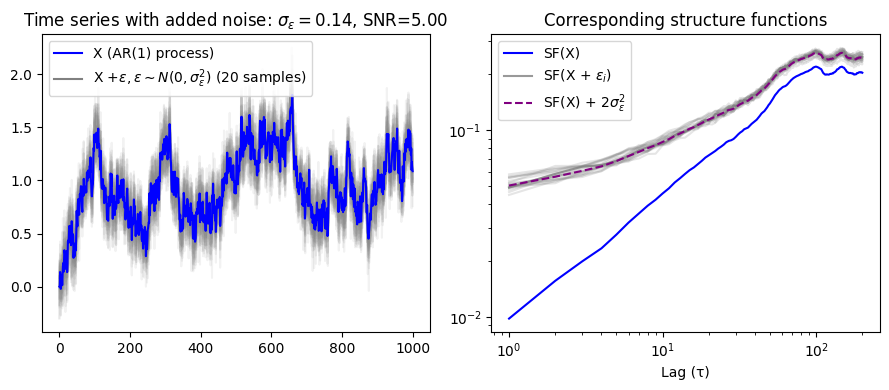

In [106]:
snr = 5  # Signal-to-noise ratio
sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=ts_sim, max_lag=200, snr=snr, n_samples=20, data_name="AR(1) process"
)

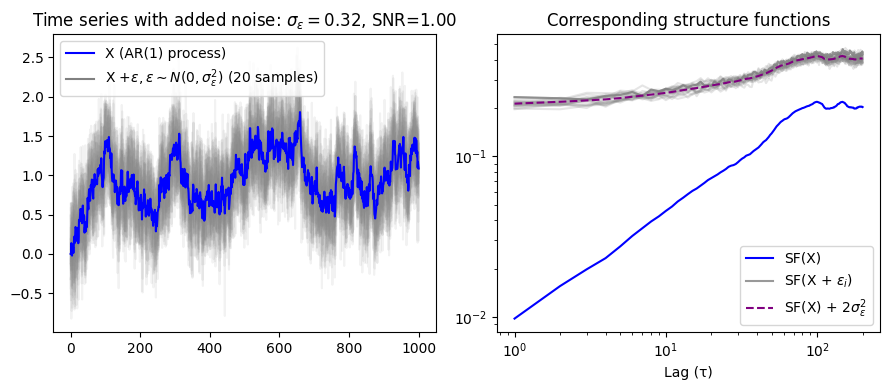

In [107]:
snr = 1
sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=ts_sim, max_lag=200, snr=snr, n_samples=20, data_name="AR(1) process"
)

We can see that measurement noise mostly impacts small scales (small $\tau$) because that's where the signal differences are small and more susceptible to noise, resulting in a flattening of the curve.

### Demo on Voyager data

- As a demonstration dataset, we'll be working with the some magnetic field data from the Local Interstellar Medium, as measured by Voyager 2. The radial component of this data has particularly large measurement errors.
- NB: Low signal-to-noise ratio for Voyager is making corrected-SF negative. **Try just adding Gaussian noise with given sigma to time series, and run a bootstrap-like model with this. Compare this to corrected values.**

In [108]:
data_full = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
data_res = data_full.resample("48s").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7461001 entries, 2012-08-25 00:00:00 to 2023-12-31 00:00:00
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 170.8 MB


In [109]:
# Extract study interval
ts_v1 = data_res[:20000]["BN"]
len(ts_v1.dropna())

7283

In [130]:
# Block bootstrap implementation
def noise_bootstrap_sf(x, max_lag, sigma, n_bootstraps=1000):
    n = len(x)
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):
        x_boot = x + np.random.normal(0, sigma, len(x))
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    return sf_boot, x_boot_all

# Compute original SF and bootstrapped confidence intervals
# For Voyager data
ts = ts_v1
ts.reset_index(drop=True, inplace=True)

max_lag = 200

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], False, False, None
)

n_bootstraps = 50
snr = np.var(ts) / sigma_eps**2  # Signal-to-noise ratio

sf_boot, x_boot = noise_bootstrap_sf(ts, max_lag, sigma_eps, n_bootstraps)

sf_noise = sf_funcs.compute_sf(
    pd.DataFrame(np.random.normal(0, sigma_eps, len(ts))),
    np.arange(1, max_lag + 1),
    [2],
    False,
    False,
    None,
)

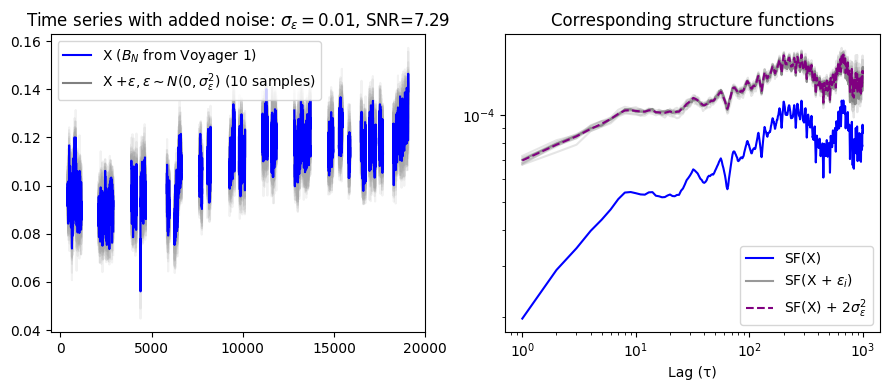

In [111]:
sigma_eps = 0.005  # Standard deviation of noise, from Rankin et al. (2023)

sf_true, sf_boot, sf_noise, x_boot_all, snr, sigma_eps = simulate_noise(
    x=ts_v1,
    max_lag=1000,
    sigma_eps=sigma_eps,  
    n_samples=10,
    data_name="$B_N$ from Voyager 1",
    plot_minus=False,
)

## Sampling uncertainty

We want to model the uncertainty under repeated measurement scenarios, and therefore assess the robustness of estimated scaling behaviour: if we were to observe a slightly different interval, how much could the SF differ? We know that it could differ by a larger amount at large $\tau$ (fewer sample pairs contribute), and higher-order structure functions (sensitive to rare, extreme events.)



 To do this, we would like to know the distribution of estimates of the structure function.

The second-order structure function $\text{SF}(\tau)$, like any variance, is a positively skewed quantity, especially at small sample sizes. ([Emmanoulopoulos et al. (2010)](https://academic.oup.com/mnras/article-abstract/404/2/931/968488) suggest in their Fig. 8 that its distribution may be approximately log-normal at certain lags.)

In the ideal case of Gaussian data, [the sample variance follows a scaled chi-squared distribution](https://en.wikipedia.org/wiki/Variance#Population_variance_and_sample_variance). The standard error of the sample variance is then given by:

$$
\hat{\sigma}_{S^2} = S^2 \sqrt{\frac{2}{n - 1}}
$$

Applied to the structure function, this gives an approximate standard error:

$$
\sigma_{\text{SF}}(\tau) = \text{SF}(\tau) \sqrt{\frac{2}{N(\tau) - 1}}
$$

where $N(\tau)$ is the number of increment pairs at lag $\tau$. However, for small $N(\tau)$ or heavy-tailed data, the SF distribution can deviate strongly from normality.

As for what we specifically get when this variance is of the difference of two squared RVs: this has been derived by \citet[Appendix F]{clerc2019towards} and \citet{ortiz2002calculation}.



Bootstrapping is a way to do this that involves re-sampling the original data, with replacement, in order to generate "plausible alternative realisations" of the data. Doing this in blocks preserves (at least the short-range component of) the correlation structure that we need for a time series.

However, we need to be transparent about what properties are being preserved, and what aren't (i.e., long-run correlations.)

### Simulated data

In [164]:
def block_bootstrap_sf(x, max_lag, block_size, n_bootstraps=1000, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    n = len(x)
    n_blocks = n // block_size
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):
        indices = np.random.randint(0, n_blocks, n_blocks)
        x_boot = np.concatenate(
            [x[i * block_size : (i + 1) * block_size] for i in indices]
        )
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    return sf_boot, x_boot_all


# Parameters
block_size = 2000
n_bootstraps = 5

# Compute original SF and bootstrapped confidence intervals
# For Voyager data
ts = ts_v1

sf_true = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag+1), [2], True, False, None
)
sf_boot, x_boot = block_bootstrap_sf(ts, max_lag, block_size, n_bootstraps)

In [165]:
# Conduct a normal bootstrap
def normal_bootstrap_sf(x, max_lag, n_bootstraps=1000):
    n = len(x)
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):
        indices = np.random.choice(range(n), size=n, replace=True)
        x_boot = x[indices]
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    return sf_boot, x_boot_all

In [189]:
def visualize_block_index_mapping(
    original, boot_samples, block_size, n_samples=2, data_name=""
):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    n = len(original)
    n_blocks = n // block_size

    fig, axes = plt.subplots(
        n_samples + 1, 1, figsize=(10, 1.5 * (n_samples + 1)), sharex=True
    )

    # --- Original Time Series ---
    ax0 = axes[0]
    # Plot non-NA values and indicate NA values
    valid_mask = ~pd.isna(original)
    ax0.plot(np.arange(n), np.array(original), color="black")


    for i in range(n_blocks):
        start = i * block_size
        ax0.axvline(start, linestyle="--", alpha=0.5, color="black")

        ypos = np.nanmax(original) * 0.5
        if np.isnan(ypos):  # Handle case where all data might be NaN
            ypos = 0.5

        ax0.text(
            start + block_size / 2,
            ypos,
            f"{i}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
        )
    ax0.set_title(
        f"Original time series ({data_name}) with block indices", fontweight="bold"
    )
    ax0.axvline(n, linestyle="--", alpha=0.5, color="black")

    # --- Bootstrapped Samples ---
    for sample_idx in range(n_samples):
        sample = boot_samples[sample_idx]
        ax = axes[sample_idx + 1]

        # Plot non-NA values in the bootstrap sample
        valid_mask_sample = ~pd.isna(sample)
        if np.any(valid_mask_sample):
            ax.plot(
                np.arange(len(sample)),
                np.array(sample),
                color="black",
                lw=0.5,
            )

        # Mark NA positions in bootstrap sample
        for i in range(0, len(sample), block_size):
            block = sample[i : i + block_size]

            # Identify origin block
            found_origin = -1
            for j in range(n_blocks):
                orig_block = original[j * block_size : (j + 1) * block_size]
                orig_block_size = min(block_size, len(orig_block))

                # Compare blocks accounting for NAs
                if block_matches_with_na(
                    block[:orig_block_size], orig_block[:orig_block_size]
                ):
                    found_origin = j
                    break

            ax.axvline(i, linestyle="--", alpha=0.7, color="black")

            ypos = np.nanmax(sample) * 0.5
            if np.isnan(ypos):  # Handle case where all data might be NaN
                ypos = 0.5

            ax.text(
                i + block_size / 2,
                ypos,
                f"{found_origin}",
                ha="center",
                va="bottom",
                fontsize=9,
                bbox=dict(
                    facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"
                ),
            )

        # Add final vertical line for the last block
        ax.axvline(len(sample), linestyle="--", alpha=0.7, color="black")
        ax.set_title(f"Bootstrapped Sample ({sample_idx + 1})")

    plt.tight_layout()
    plt.show()


def block_matches_with_na(block1, block2):
    """
    Check if two blocks match, accounting for NA values.
    Two blocks match if:
    1. Non-NA values in the same positions are close to each other
    2. NA patterns match (NA in block1 corresponds to NA in block2)
    """
    import numpy as np
    import pandas as pd

    # Convert to numpy arrays if they aren't already
    block1 = np.array(block1)
    block2 = np.array(block2)

    # Check if lengths match
    if len(block1) != len(block2):
        return False

    # Create masks for NA values
    mask1 = pd.isna(block1)
    mask2 = pd.isna(block2)

    # Check if NA patterns match
    if not np.array_equal(mask1, mask2):
        return False

    # For non-NA values, check if they are close
    non_na_indices = ~mask1  # Same as ~mask2 since we've verified they're equal

    # If all values are NA, blocks match
    if not np.any(non_na_indices):
        return True

    # Check if non-NA values are close
    return np.allclose(block1[non_na_indices], block2[non_na_indices], atol=1e-6)

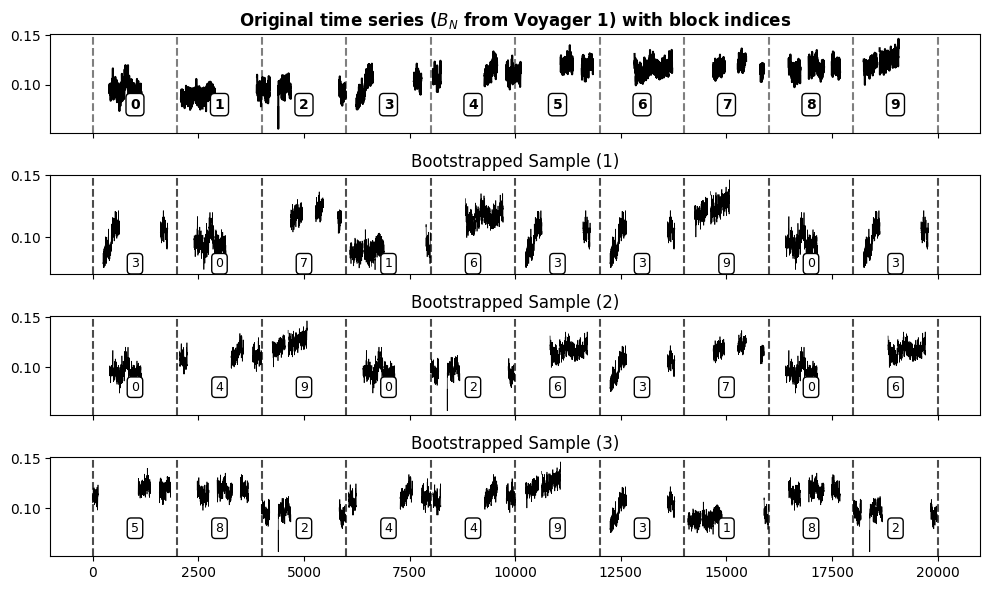

In [191]:
# Adjust block_size to be less than or equal to the length of ts_v1
visualize_block_index_mapping(
    ts_v1, x_boot, block_size, n_samples=3, data_name="$B_N$ from Voyager 1"
)

Block bootstrapping perserves short-to-intermdiate scale autocorrelations, depending on the blocksize.
We need to make sure 
- the block size is large enough to retain sufficient autocorrelation, i.e., **block size > max lag > $\lambda_C$**
- given this block size, the signal is long enough for many blocks.

Also note, 
- this method will not preserve sharp gradients or bursts, i.e. *intermittency*, unless they're fully contained in blocks.

Overlapping blocks is less 'chunky' and preserves local dependencies somewhat better.

In [135]:
def get_lag_vals_list(df):
    lag_vals_wide = pd.DataFrame(df["diffs_2"].tolist(), index=df.index)
    lag_vals_wide.reset_index(inplace=True)  # Make the index a column
    lag_vals_wide.rename(columns={"index": "lag"}, inplace=True)
    lag_vals = pd.melt(
        lag_vals_wide, id_vars=["lag"], var_name="index", value_name="diffs_2"
    )
    return lag_vals

KeyboardInterrupt: 

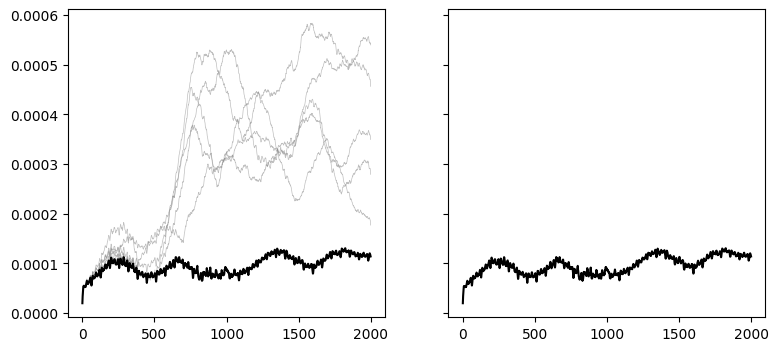

In [ ]:
ci_lower = np.percentile(sf_boot, 2.5, axis=0)
ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Calculate standard error assuming chi-squared approximation (pointwise error bars)
n_pairs = np.array([len(ts) - tau for tau in range(1, max_lag + 1)])
sf_se = sf_true.sf_2 * np.sqrt(2 / (n_pairs - 1))
ci_se_lower = sf_true.sf_2 - 1.96 * sf_se
ci_se_upper = sf_true.sf_2 + 1.96 * sf_se

# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax
fig, ax = plt.subplots(1,2, figsize=(9, 4), sharey=True)
for sf in sf_boot:
    ax[0].plot(lags-1, sf, color="grey", alpha=0.5, lw=0.5)
ax[0].plot(lags[0]-1, sf_boot[0][0], color="grey", alpha=0.8, lw = 0.5, label="Bootstrapped SFs")
ax[0].plot(lags-1, sf_true.sf_2, label="Original SF", color="black")
ax[1].plot(lags-1, sf_true.sf_2, color="black")


lag_vals = get_lag_vals_list(sf_true)

# sns.pointplot(
#     x="lag",
#     y="diffs_2",
#     data=lag_vals,
#     alpha=0.5,
#     errorbar="ci",
#     marker=None,
#     c="purple",
#     ax=ax[1],
#     estimator="mean",
#     lw=0.8,
# )
ax[0].fill_between(
    lags-1, ci_lower, ci_upper, color="blue", alpha=0.2
)

ax[1].fill_between(
    lags-1,
    ci_se_lower,
    ci_se_upper,
    color="purple",
    alpha=0.2,
)

# ax[1].plot(bootstrap_means_df.index - 1, bootstrap_means_df, c="grey", alpha=0.1)

ax[0].set_xlabel("Lag (τ)")
ax[0].set_ylabel("SF(τ)")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title("Joint 95% C.I. using bootstrapped $X$")
ax[0].legend(loc="lower right")

ax[1].set_xlabel("Lag (τ)")
ax[1].set_title("Pointwise 95% C.I. using bootstrapped $[\Delta X(\\tau)]^2$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

fig.tight_layout()
plt.show()

#### fBm

Uh-oh. Block-bootstrapped fBm time series have seriously inflated SF values, especially at small lags. This is likely from the introduction of artificial sharp discontinuities (**intermittency**) at block boundaries. At large lags, the SFs cluster around the true SF, as these are less affected, and the total signal variance at which the SF plateaus, is not biased by the bootstrapping procedure.


#### AR(1)

We can see that the bootstrap interval is generally wider, especially at larger lags, reflecting the additional uncertainty due to autocorrelation and non-Gaussianity.

The confidence interval on the right, based on the theoretical standard error of the sample variance, is approximately equal to the bootstrap confidence interval at a given lag (i.e., resampling with replacement the squared increments at that lag.) *This suggests that the raw differences are Gaussian enough, or the sample sizes large enough, for this convergence to occur.*

MAKE CONCLNUSION, TIDY, TRY BOTH ON VOYAGER, CF WITH DOC, CHUCK IN KIYANI, JAG, ISAACS -> WRAP UP!

MAKE CLEAR NOTES FOR WHAT NEEDS TO BE DONE FOR PAPER! READY TO SUBMIT? MAKE VOYAGER DRAFT!

In [137]:
# MANUAL POINTWISE BOOTSTRAP OF SQUARED DIFFERENCES
# (this is already achieved by seaborn's sns.pointplot() above)

# Initialize a dictionary to store the mean squared differences for each lag
bootstrap_means = {}

# Perform bootstrapping for 10 resamples
n_resamples = 100
for lag in lag_vals["lag"].unique():
    bootstrap_means[lag] = []
    for _ in range(n_resamples):
        sq_diffs = lag_vals[lag_vals['lag'] == lag]["diffs_2"]
        sq_diffs_resampled = sq_diffs.sample(frac=1.0, replace=True, random_state=None)
        mean_sq_diff = np.mean(sq_diffs_resampled)
        bootstrap_means[lag].append(mean_sq_diff)

# Convert the results to a DataFrame for easier analysis
bootstrap_means_df = pd.DataFrame(bootstrap_means)

# Switch rows and columns
bootstrap_means_df = bootstrap_means_df.transpose()

### Voyager data

## Fit uncertainty

For this, we simply fit our slopes to each of our bootstrapped SFs and report the distribution of these.

### Simulated data

### Voyager data

# Bonus
Daily averages of V1 LISM are very K41 monofractal! Certainly suggests not yet at outer scale...

In [138]:
data_res = data_full.resample("1d").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4146 entries, 2012-08-25 to 2023-12-31
Freq: D
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      3969 non-null   float32
 1   BR      3969 non-null   float32
 2   BT      3969 non-null   float32
 3   BN      3969 non-null   float32
dtypes: float32(4)
memory usage: 97.2 KB


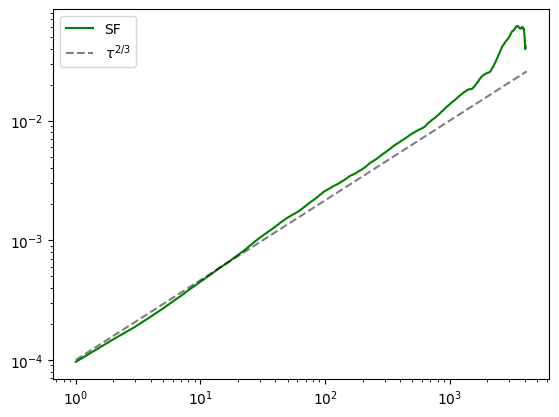

In [139]:
max_lag = 2000

sf_true = sf_funcs.compute_sf(
    data_res[["BR", "BT", "BN"]], np.arange(1, len(data_res)), [2], False, False, None
)

plt.plot(
    sf_true.lag,
    sf_true.sf_2,
    label="SF",
    color="green",
)

# Plot 2/3 power law
plt.plot(
    sf_true.lag,
    0.0001 * np.power(sf_true.lag, 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle="--",
    alpha=0.5,
)
plt.legend()
plt.xscale("log")
plt.yscale("log")